Setup basic parameters.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
import re

s = Simulation()
Nt = 100
tg = 250
tlist = np.linspace(0, tg, Nt)
cos_amp, cos_wd = compute_cos_params(s, tg)

lh = [s.H0, [s.V1, lambda t, args: cos_amp * np.cos(cos_wd * t)]]
psi0 = Qobj(s.E_states[s.state_a])
psi0_dressed = np.zeros(27)
psi0_dressed[s.state_a] = 1

Read the precomputed wave function psi_t_floq, that is predicted by floquet theory at order rH=5/rW=1. Also read in the pulse shape parameters that were used to achieve that simulation.

In [2]:
from pathlib import Path
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
psi_t_file = coeff_dir / 'psi_t_rW1rH5.rtf'

with open(psi_t_file) as f:
    text = f.read()

# Alle Zeitpunkte und zugehörigen psi_t-Arrays finden
pattern = r"t:\s*([0-9eE+.\-]+)\s*psit:\s*\[(.*?)\]"
matches = re.findall(pattern, text, re.DOTALL)

times = []
psi_t_floq = []

for t_str, psi_str in matches:
    # Zeilenumbrüche entfernen
    psi_str = psi_str.replace("\n", " ")

    # Alle komplexen Zahlen extrahieren
    complex_strings = re.findall(
        r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?[-+]\d*\.?\d+(?:e[-+]?\d+)?j",
        psi_str
    )
    psi = np.array([complex(s) for s in complex_strings])
    psi_t_floq.append(psi)
psi_t_floq = np.array(psi_t_floq)

signal_file = coeff_dir / f"precomputed_heff_modulated{tg}_{Nt}.pkl"
with open(signal_file, 'rb') as f:
    heff_data = pickle.load(f)
print(f"signal loaded from {signal_file}")
freq = heff_data['frequency']
amp_real = heff_data['amplitude_real']
amp_imag = heff_data['amplitude_imag']

def drive_signal_interp(t, fc, arc, aic):
    if t <= tlist[0]:
        return [freq[0],0]
    if t >= tlist[-1]:
        return [freq[-1],0]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    ar = (1 - alpha) * arc[idx] + alpha * arc[idx + 1]
    ai = (1 - alpha) * aic[idx] + alpha * aic[idx + 1]
    wd = (1 - alpha) * fc[idx] + alpha * fc[idx + 1]
    return [wd, ar + 1j*ai]

signal loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated250_100.pkl


Plot the two time evolutions, the one predicted by floquet theory and the one determined with the precomputed pulse shape functions wd(t) and amp(t)

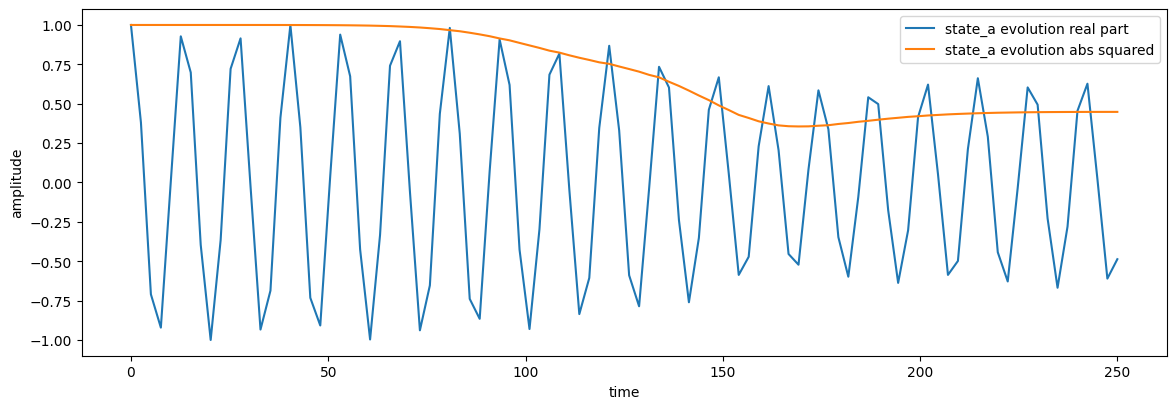

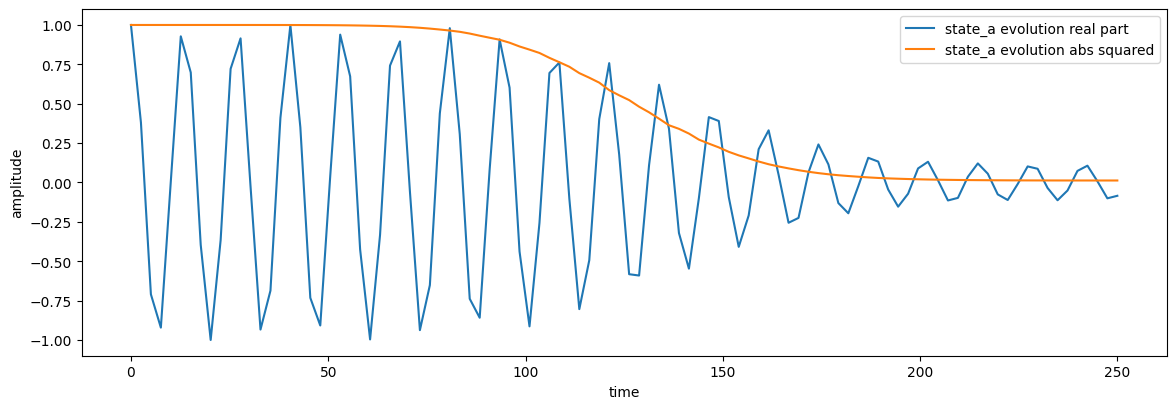

100it [00:08, 12.11it/s]


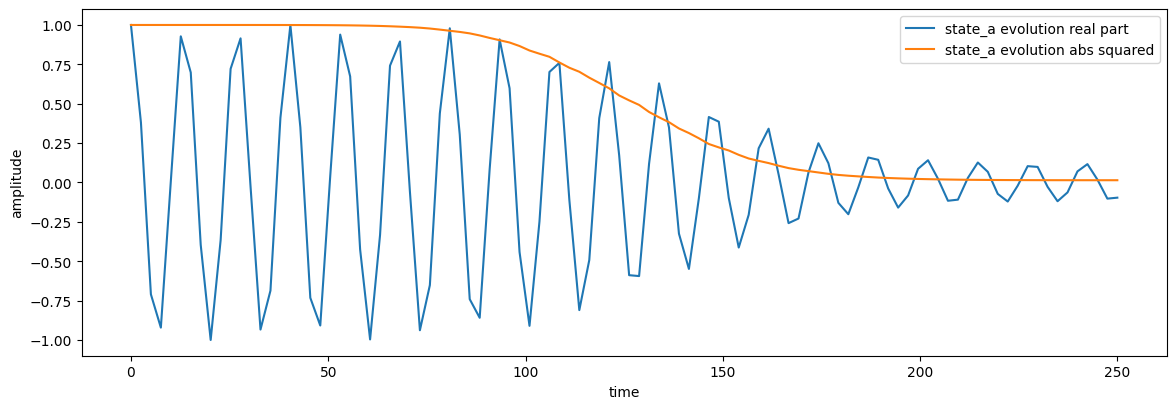

In [3]:
def plot_a_evolution(psi_a,):
    _, ax = plt.subplots(1, 1, figsize=(14, 4.5))
    ax.plot(tlist, np.real(psi_a), label='state_a evolution real part')
    ax.plot(tlist, np.abs(psi_a)**2, label='state_a evolution abs squared')
    ax.plot()
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel('amplitude')
    plt.show()

# Gaus DRAG direct simulation
def signal(t, args=None):
    s = drive_signal_interp(t, freq, amp_real, amp_imag)
    return s[1] * np.cos(s[0]*t) 
result = mesolve([s.H0, [s.V1, signal]], psi0, tlist, e_ops=[])
psi_a = [result.states[i].overlap(Qobj(s.E_states[s.state_a])) for i in range(Nt)]
plot_a_evolution(psi_a)

# Gauss DRAG precomputed floquet simulation order rH=5/rW=1
plot_a_evolution(psi_t_floq[:,s.state_a])

# Gauss Drag floquet prediction of order rH=3/rW=1
rH = 3
rW = 1
psi_floq, _ = Psi_t_FloquetPerturb_dynamic(rH, rW, lambda t: drive_signal_interp(t, freq, amp_real, amp_imag),
                                            s.resonances, s.E_array, s.V1_dressed_array, psi0_dressed, tlist, num = True)
psi_a_floq = psi_floq[s.state_a, :]
plot_a_evolution(psi_a_floq)